Coherence $c_i\in\{-1,+1\}$ is equally likely and sets the correct direction (L/R). With centered pupil $p_i$, simulated drift is $v_i=c_i(\beta_1+\beta_2p_i)$; $a$, $t_0$, and $z$ are constant.

Coherence sets drift direction; pupil modulates its magnitude. Both fits include coherence. The Covariate 4p Fit also includes pupil effects on all four parameters.

The conditional accuracy function (CAF) pools trials using the coherence-defined correct boundary:

$$P(\mathrm{correct}\mid RT=t)=\frac{\sum_i f_{i,\mathrm{correct}}(t)}{\sum_i[f_{i,L}(t)+f_{i,R}(t)]},$$

where $f_{i,L}$ and $f_{i,R}$ are joint RT and response densities. Curves are computed directly from these densities, without RT binning.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils import conditional_accuracy, slow_traces

from drift_diffusion.model import DriftDiffusionModel
from drift_diffusion.sim import sample_from_pdf

trial_dur, pupil_tau, seed, n_trials = 1.0, 20.0, 7, 1000
rng = np.random.default_rng(seed)

In [2]:
# one slow pupil trace shared across trials
pupil = 0.5 + 0.15 * slow_traces(rng, 1, n_trials, pupil_tau / trial_dur)[0]
pupil_centered = pupil - pupil.mean()
coherence = rng.choice([-1, 1], n_trials)

# positive coherence means R is correct; positive drift favors R
v_min, v_max = 0.1, 2.23 + 1.33 * np.sqrt(3)
beta_pupil = (v_max - v_min) / np.ptp(pupil)
beta_coherence = v_min + beta_pupil * (pupil.mean() - pupil.min())
v_pupil = coherence * (beta_coherence + beta_pupil * pupil_centered)
params = dict(a=0.63, t0=0.435, v=v_pupil, z=0.008)

ys = sample_from_pdf(**params, n_samples=n_trials, random_state=0)
choices, rts = np.sign(ys), np.abs(ys)

print(f"v range: {v_pupil.min():.3f} to {v_pupil.max():.3f}")
print(f"accuracy: {(choices == np.sign(coherence)).mean():.3f}")

v range: -4.533 to 4.534
accuracy: 0.889


In [3]:
X = pd.DataFrame({"coherence": coherence, "pupil_centered": pupil_centered})
param_names = ("a", "t0", "v", "z")
formulas = {name: "+1 + pupil_centered" for name in param_names}
formulas["v"] = "0 + coherence + coherence:pupil_centered"
ddm_varying = DriftDiffusionModel(**formulas).fit(X, ys)
formulas = {name: "+1" for name in param_names}
formulas["v"] = "0 + coherence"
ddm_constant = DriftDiffusionModel(**formulas).fit(X, ys)

estimate = ddm_varying.params_.reshape(len(param_names), 2)
se = np.sqrt(np.diag(ddm_varying.covariance_)).reshape(len(param_names), 2)

for i, name in enumerate(param_names):
    print(
        f"{name} pupil slope: true={beta_pupil if name == 'v' else 0:.3f}, fitted={estimate[i, 1]:.3f} +/- {se[i, 1]:.3f}"
    )
constant_v = ddm_constant.params_[2]
constant_v_se = np.sqrt(ddm_constant.covariance_[2, 2])
print(f"coherence coefficient: true={beta_coherence:.3f}, fitted={constant_v:.3f} +/- {constant_v_se:.3f}")

a pupil slope: true=0.000, fitted=-0.216 +/- 0.099
t0 pupil slope: true=0.000, fitted=0.044 +/- 0.022
v pupil slope: true=7.631, fitted=7.807 +/- 0.504
z pupil slope: true=0.000, fitted=0.041 +/- 0.110
coherence coefficient: true=2.222, fitted=1.713 +/- 0.066


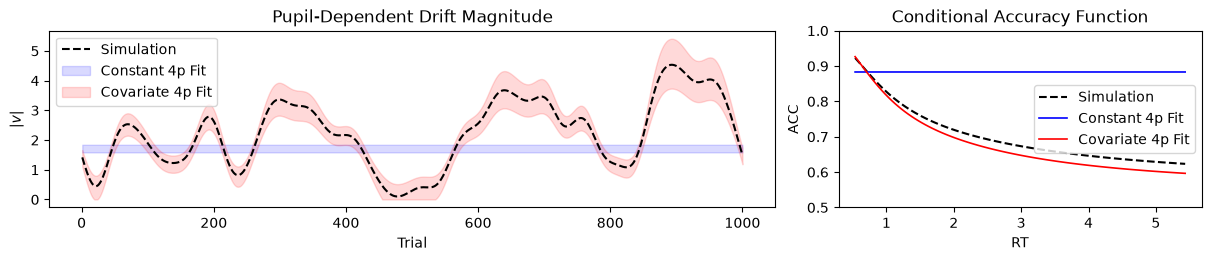

In [4]:
v_band = ddm_varying.g(X, alpha=0.05 / n_trials)["v"]
constant_band = ddm_constant.g(X)["v"]
trial = np.arange(1, n_trials + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 2.5), width_ratios=[2, 1], layout="constrained")

axs[0].plot(trial, np.abs(v_pupil), "--", color="k", label="Simulation")
for band, color, label in [(constant_band, "b", "Constant 4p Fit"), (v_band, "r", "Covariate 4p Fit")]:
    lower, upper = band["-"], band["+"]
    abs_lower = np.where((lower <= 0) & (upper >= 0), 0, np.minimum(np.abs(lower), np.abs(upper)))
    abs_upper = np.maximum(np.abs(lower), np.abs(upper))
    axs[0].fill_between(trial, abs_lower, abs_upper, color=color, alpha=0.15, label=label)
axs[0].set_title("Pupil-Dependent Drift Magnitude")
axs[0].set_xlabel("Trial")
axs[0].set_ylabel(r"$|v|$")

rt_grid = np.linspace(params["t0"] + 0.1, params["t0"] + 5, 100)

axs[1].plot(
    rt_grid,
    conditional_accuracy(rt_grid, **params, correct_boundary=np.sign(coherence)),
    "--",
    color="k",
    label="Simulation",
)
for ddm, color, label in [(ddm_constant, "b", "Constant 4p Fit"), (ddm_varying, "r", "Covariate 4p Fit")]:
    params_fit = {name: band["g"] for name, band in ddm.g(X).items()}
    axs[1].plot(
        rt_grid,
        conditional_accuracy(rt_grid, **params_fit, correct_boundary=np.sign(coherence)),
        color=color,
        lw=1.2,
        label=label,
    )
axs[1].set(xlabel="RT", ylabel="ACC", ylim=(0.5, 1.0), title="Conditional Accuracy Function")

axs[0].legend()
axs[1].legend()